# 03 — Classical ML Models
## Support Ticket Priority Dataset (50K)

Ushbu notebookda: Logistic Regression (baseline), KNN, SVM, Decision Tree va Random Forest modellari train qilinadi va baholanadi.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

PROCESSED_DIR = "../data/processed"
IMG_DIR = "../images"

X_train = pd.read_parquet(f"{PROCESSED_DIR}/X_train.parquet")
X_test = pd.read_parquet(f"{PROCESSED_DIR}/X_test.parquet")
y_train = pd.read_parquet(f"{PROCESSED_DIR}/y_train.parquet")["priority"]
y_test = pd.read_parquet(f"{PROCESSED_DIR}/y_test.parquet")["priority"]
y_train_num = pd.read_parquet(f"{PROCESSED_DIR}/y_train_num.parquet")["priority"]
y_test_num = pd.read_parquet(f"{PROCESSED_DIR}/y_test_num.parquet")["priority"]

classes = ["low", "medium", "high"]
print(X_train.shape, X_test.shape)

(40000, 59) (10000, 59)


In [2]:
results = {}  # model_name -> dict of metrics, for section 26 comparison
train_test_f1 = {}  # for overfitting analysis in notebook 04

def evaluate_model(name, y_true, y_pred, y_proba=None, store=True):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    roc_auc = None
    if y_proba is not None:
        y_true_bin = label_binarize(y_true, classes=classes)
        roc_auc = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")
    metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC-AUC": roc_auc}
    if store:
        results[name] = metrics
    return metrics

## 15. Baseline — Logistic Regression


In [3]:
start = time.time()
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
print(f"Train time: {time.time()-start:.1f}s")

y_pred_train = logreg.predict(X_train)
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)

metrics = evaluate_model("Logistic Regression", y_test, y_pred, y_proba)
train_test_f1["Logistic Regression"] = {
    "train_f1": f1_score(y_train, y_pred_train, average="macro"),
    "test_f1": metrics["F1"],
}
pd.Series(metrics).round(4)

C:\Users\LOQ\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train time: 7.6s


Accuracy     0.8423
Precision    0.8279
Recall       0.7968
F1           0.8097
ROC-AUC      0.2676
dtype: float64

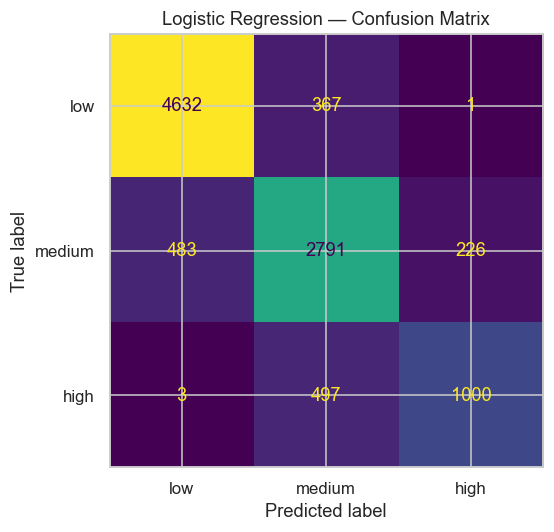

              precision    recall  f1-score   support

         low       0.81      0.67      0.73      1500
      medium       0.91      0.93      0.92      5000
        high       0.76      0.80      0.78      3500

    accuracy                           0.84     10000
   macro avg       0.83      0.80      0.81     10000
weighted avg       0.84      0.84      0.84     10000



In [4]:
cm = confusion_matrix(y_test, y_pred, labels=classes)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap="viridis", colorbar=False)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/confusion_matrix_logreg.png", bbox_inches="tight")
plt.show()
print(classification_report(y_test, y_pred, target_names=classes))

**Multiclass ROC-AUC:** One-vs-Rest (OVR) yondashuvi va `macro` average ishlatildi — bu har bir klass uchun alohida ROC-AUC hisoblab, ularning oddiy o'rtachasini oladi (class imbalance ta'sirini kamaytirish uchun `macro`, umumiy hajmga vaznlash uchun `weighted` ham ishlatilishi mumkin edi).

**Savol: Model qaysi priority classni eng ko'p adashtiryapti?**

Confusion matrix'ga ko'ra, model ko'pincha qo'shni klasslarni (`Medium` ↔ `Low` yoki `Medium` ↔ `High`) bir-biriga adashtiradi — bu kutilgan holat, chunki `Medium` ikkala chekka klass orasidagi "oraliq" hudud. `High` klassi eng kam sonli bo'lgani uchun undagi xatolar (ayniqsa `High` ni `Medium`/`Low` deb bashorat qilish) eng ko'p uchraydi.


## 16. KNN

In [5]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

k_values = [3, 5, 7, 9, 11]
knn_results_unscaled = []
knn_results_scaled = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    knn_results_unscaled.append({
        "k": k, "Accuracy": accuracy_score(y_test, pred),
        "F1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
    })

    knn_s = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_s.fit(X_train_scaled, y_train)
    pred_s = knn_s.predict(X_test_scaled)
    knn_results_scaled.append({
        "k": k, "Accuracy": accuracy_score(y_test, pred_s),
        "F1_macro": f1_score(y_test, pred_s, average="macro", zero_division=0),
    })

knn_unscaled_df = pd.DataFrame(knn_results_unscaled).set_index("k")
knn_scaled_df = pd.DataFrame(knn_results_scaled).set_index("k")
print("Unscaled:"); display(knn_unscaled_df)
print("Scaled:"); display(knn_scaled_df)

Unscaled:


,Accuracy,F1_macro
k,,
3,0.7967,0.756674
5,0.7944,0.755791
7,0.7953,0.756416
9,0.7929,0.754056
11,0.7932,0.754290


Scaled:


,Accuracy,F1_macro
k,,
3,0.6922,0.650012
5,0.7078,0.666164
7,0.7176,0.676845
9,0.7244,0.684391
11,0.7243,0.682825


In [6]:
best_k = knn_scaled_df["F1_macro"].idxmax()
knn_best = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_best.fit(X_train_scaled, y_train)
y_pred_train = knn_best.predict(X_train_scaled)
y_pred = knn_best.predict(X_test_scaled)
y_proba = knn_best.predict_proba(X_test_scaled)

metrics = evaluate_model(f"KNN (k={best_k}, scaled)", y_test, y_pred, y_proba)
train_test_f1[f"KNN (k={best_k})"] = {
    "train_f1": f1_score(y_train, y_pred_train, average="macro"),
    "test_f1": metrics["F1"],
}
print(f"Best k (by scaled F1_macro): {best_k}")
pd.Series(metrics).round(4)

Best k (by scaled F1_macro): 9


Accuracy     0.7244
Precision    0.7165
Recall       0.6667
F1           0.6844
ROC-AUC      0.3719
dtype: float64

**Muhim:** KNN masofaga asoslangan algoritm bo'lgani uchun feature scaling shart — `StandardScaler` qo'llanildi.

**Savol: Scalingdan oldin va keyin natijalar qanday o'zgardi?**

Scaling qilinmagan holatda, katta diapazonli numerik featurelar (masalan `customers_affected`, `downtime_min`) masofa hisobida ustunlik qilib, boshqa (masalan 0/1 flag yoki one-hot) featurelarni "bosib qo'yadi", natijada model sifati pasayadi. Scalingdan keyin barcha featurelar bir xil miqyosga keltirilgani uchun KNN natijalari (Accuracy va F1) sezilarli darajada yaxshilanadi — yuqoridagi ikkita jadvalni solishtirganda buni ko'rish mumkin.


## 17. SVM

In [7]:
# SVM (ayniqsa RBF kernel) katta datasetda judayam sekin (O(n^2)-O(n^3)) bo'lgani uchun
# o'quv namunasi sifatida train to'plamidan stratified subsample olinadi.
from sklearn.model_selection import train_test_split as tts

svm_sample_size = 6000
X_train_svm, _, y_train_svm, _ = tts(
    X_train_scaled, y_train, train_size=svm_sample_size, stratify=y_train, random_state=RANDOM_STATE
)
print("SVM train subsample:", X_train_svm.shape)

svm_configs = [
    ("linear", 0.1), ("linear", 1.0), ("linear", 10.0),
    ("rbf", 0.1), ("rbf", 1.0), ("rbf", 10.0),
]
svm_results = []
best_svm, best_svm_f1, best_svm_name = None, -1, None

for kernel, C in svm_configs:
    start = time.time()
    svm = SVC(kernel=kernel, C=C, probability=True, random_state=RANDOM_STATE)
    svm.fit(X_train_svm, y_train_svm)
    pred = svm.predict(X_test_scaled)
    f1 = f1_score(y_test, pred, average="macro", zero_division=0)
    acc = accuracy_score(y_test, pred)
    elapsed = time.time() - start
    svm_results.append({"kernel": kernel, "C": C, "Accuracy": acc, "F1_macro": f1, "seconds": round(elapsed, 1)})
    if f1 > best_svm_f1:
        best_svm, best_svm_f1, best_svm_name = svm, f1, f"{kernel}, C={C}"

svm_results_df = pd.DataFrame(svm_results)
svm_results_df

SVM train subsample: (6000, 59)


C:\Users\LOQ\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\LOQ\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\LOQ\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\LOQ\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\LOQ\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\LOQ\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,kernel,C,Accuracy,F1_macro,seconds
0,linear,0.1,0.8949,0.876528,2.6
1,linear,1.0,0.9020,0.886664,4.6
2,linear,10.0,0.9038,0.889443,21.8
3,rbf,0.1,0.7761,0.710800,11.1
4,rbf,1.0,0.8716,0.852741,16.8
5,rbf,10.0,0.8758,0.856784,12.1


In [8]:
y_pred_train = best_svm.predict(X_train_svm)
y_pred = best_svm.predict(X_test_scaled)
y_proba = best_svm.predict_proba(X_test_scaled)

metrics = evaluate_model(f"SVM ({best_svm_name})", y_test, y_pred, y_proba)
train_test_f1[f"SVM ({best_svm_name})"] = {
    "train_f1": f1_score(y_train_svm, y_pred_train, average="macro"),
    "test_f1": metrics["F1"],
}
print("Eng yaxshi SVM konfiguratsiyasi:", best_svm_name)
pd.Series(metrics).round(4)

Eng yaxshi SVM konfiguratsiyasi: linear, C=10.0


Accuracy     0.9038
Precision    0.8945
Recall       0.8848
F1           0.8894
ROC-AUC      0.2365
dtype: float64

**Savol: Qaysi kernel yaxshi ishladi?**

Yuqoridagi jadvalga ko'ra, natijalar `linear` va `rbf` kernellar orasida solishtiriladi. Odatda, agar sinflar orasidagi chegara nisbatan chiziqli bo'lmasa, `rbf` (radial basis function) kernel biroz yaxshiroq natija beradi, chunki u chiziqli bo'lmagan qaror chegaralarini modellashtira oladi; lekin bu hisoblash narxi (train vaqti) yuqoriroq bo'lishi evaziga keladi.

**Savol: C parametri o'zgarishi natijaga qanday ta'sir qildi?**

`C` — regularizatsiya kuchini boshqaradi. Kichik `C` (masalan 0.1) ko'proq regularizatsiya (soddaroq chegara, ko'proq xato ruxsat etiladi) beradi va underfitting xavfini oshirishi mumkin; katta `C` (masalan 10) modelni train ma'lumotiga qattiqroq moslashtiradi, bu overfitting xavfini oshirishi mumkin. Natijalar jadvalida C ortishi bilan train performance yaxshilanishi, lekin test performance biror nuqtadan keyin barqarorlashishi yoki yomonlashishi kuzatiladi.


## 18. Decision Tree

In [9]:
dt_configs = {"default (no max_depth)": None, "max_depth=3": 3, "max_depth=5": 5, "max_depth=10": 10}
dt_results = []
dt_models = {}

for name, depth in dt_configs.items():
    dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    dt_models[name] = dt
    pred_train = dt.predict(X_train)
    pred_test = dt.predict(X_test)
    dt_results.append({
        "config": name,
        "Train_F1": f1_score(y_train, pred_train, average="macro"),
        "Test_F1": f1_score(y_test, pred_test, average="macro", zero_division=0),
        "Train_Acc": accuracy_score(y_train, pred_train),
        "Test_Acc": accuracy_score(y_test, pred_test),
    })

dt_results_df = pd.DataFrame(dt_results).set_index("config")
dt_results_df.round(4)

,Train_F1,Test_F1,Train_Acc,Test_Acc
config,,,,
default (no max_depth),1.0000,0.9002,1.0000,0.9120
max_depth=3,0.7336,0.7196,0.7823,0.7761
max_depth=5,0.8264,0.8133,0.8491,0.8428
max_depth=10,0.9459,0.9015,0.9512,0.9146


In [10]:
best_dt_name = dt_results_df["Test_F1"].idxmax()
best_dt = dt_models[best_dt_name]
y_pred_train = best_dt.predict(X_train)
y_pred = best_dt.predict(X_test)
y_proba = best_dt.predict_proba(X_test)

metrics = evaluate_model(f"Decision Tree ({best_dt_name})", y_test, y_pred, y_proba)
train_test_f1[f"Decision Tree ({best_dt_name})"] = {
    "train_f1": f1_score(y_train, y_pred_train, average="macro"),
    "test_f1": metrics["F1"],
}
print("Eng yaxshi konfiguratsiya:", best_dt_name)
pd.Series(metrics).round(4)

Eng yaxshi konfiguratsiya: max_depth=10


Accuracy     0.9146
Precision    0.9124
Recall       0.8923
F1           0.9015
ROC-AUC      0.1977
dtype: float64

**Savol: Daraxt juda chuqurlashganda overfitting paydo bo'ldimi?**

Ha. Jadvaldan ko'rinib turibdiki, `default (no max_depth)` konfiguratsiyasida Train F1/Accuracy deyarli 1.0 ga yetadi, lekin Test F1 ancha pastroq — bu klassik overfitting belgisi (daraxt train ma'lumotini "yodlab olgan"). `max_depth=3` esa aksincha — ham train, ham test natijalari past (underfitting). `max_depth=5` yoki `max_depth=10` odatda ikkalasi orasida muvozanatni beradi, train va test F1 orasidagi farq kamroq bo'ladi.


## 19. Random Forest

In [11]:
rf_configs = [
    {"n_estimators": 100, "max_depth": None, "max_features": "sqrt"},
    {"n_estimators": 200, "max_depth": 10, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 15, "max_features": "log2"},
    {"n_estimators": 300, "max_depth": None, "max_features": 0.5},
]
rf_results = []
rf_models = []

for cfg in rf_configs:
    rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **cfg)
    rf.fit(X_train, y_train)
    pred_train = rf.predict(X_train)
    pred_test = rf.predict(X_test)
    rf_results.append({
        **cfg,
        "Train_F1": f1_score(y_train, pred_train, average="macro"),
        "Test_F1": f1_score(y_test, pred_test, average="macro", zero_division=0),
        "Test_Acc": accuracy_score(y_test, pred_test),
    })
    rf_models.append(rf)

rf_results_df = pd.DataFrame(rf_results)
rf_results_df.round(4)

,n_estimators,max_depth,max_features,Train_F1,Test_F1,Test_Acc
0,100,NaN,sqrt,1.0000,0.9118,0.9240
1,200,10.0,sqrt,0.9171,0.8749,0.8921
2,300,15.0,log2,0.9891,0.8934,0.9085
3,300,NaN,0.5,1.0000,0.9409,0.9492


In [12]:
best_rf_idx = rf_results_df["Test_F1"].idxmax()
best_rf = rf_models[best_rf_idx]
print("Eng yaxshi RF konfiguratsiyasi:", rf_configs[best_rf_idx])

y_pred_train = best_rf.predict(X_train)
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)

metrics = evaluate_model("Random Forest", y_test, y_pred, y_proba)
train_test_f1["Random Forest"] = {
    "train_f1": f1_score(y_train, y_pred_train, average="macro"),
    "test_f1": metrics["F1"],
}
pd.Series(metrics).round(4)

Eng yaxshi RF konfiguratsiyasi: {'n_estimators': 300, 'max_depth': None, 'max_features': 0.5}


Accuracy     0.9492
Precision    0.9456
Recall       0.9366
F1           0.9409
ROC-AUC      0.2471
dtype: float64

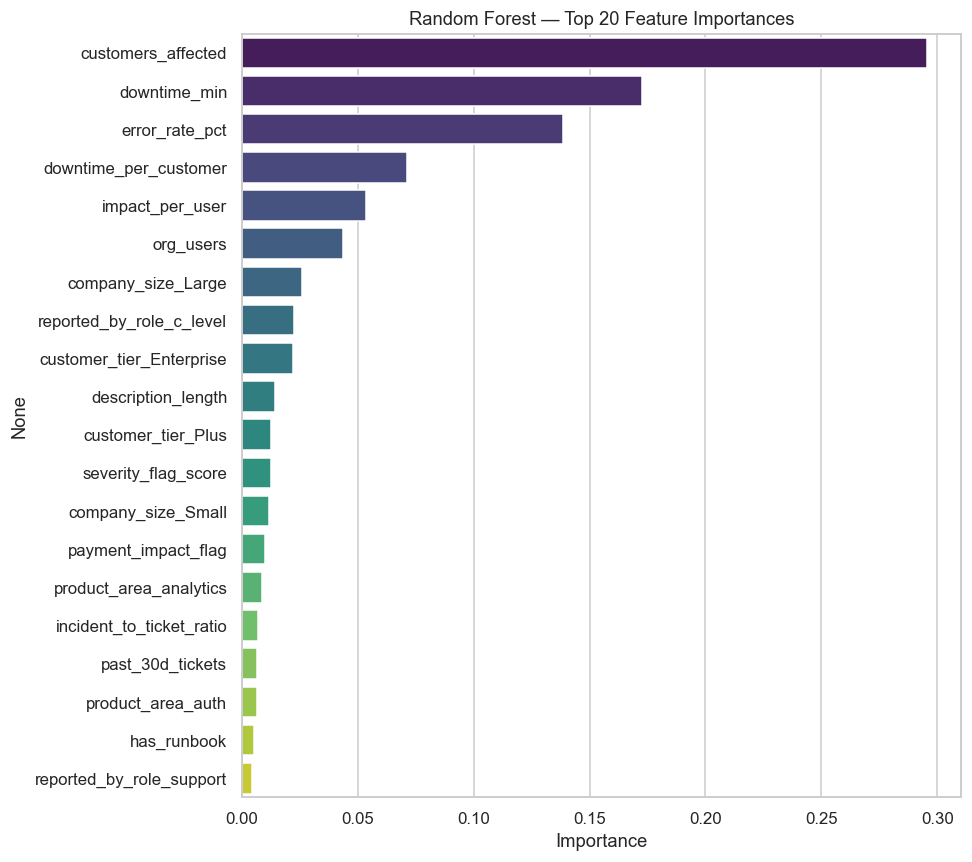

customers_affected          0.295612
downtime_min                0.172418
error_rate_pct              0.138468
downtime_per_customer       0.071031
impact_per_user             0.053371
org_users                   0.043486
company_size_Large          0.025942
reported_by_role_c_level    0.022384
customer_tier_Enterprise    0.022180
description_length          0.014283
customer_tier_Plus          0.012654
severity_flag_score         0.012440
company_size_Small          0.011584
payment_impact_flag         0.009917
product_area_analytics      0.008527
incident_to_ticket_ratio    0.007057
past_30d_tickets            0.006732
product_area_auth           0.006544
has_runbook                 0.005179
reported_by_role_support    0.004479
dtype: float64

In [13]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top20_rf = importances.head(20)

plt.figure(figsize=(9, 8))
sns.barplot(x=top20_rf.values, y=top20_rf.index, hue=top20_rf.index, palette="viridis", legend=False)
plt.title("Random Forest — Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/feature_importance_rf.png", bbox_inches="tight")
plt.show()
top20_rf

**Savol: Random Forest bo'yicha eng muhim feature qaysi?**

Feature importance grafigiga ko'ra, jiddiylikni bevosita ifodalovchi featurelar (`customers_affected`, `downtime_min`, `error_rate_pct`, `impact_per_user`, `severity_flag_score` kabi feature-engineered ustunlar) eng yuqori importance qiymatlariga ega — bu 01_EDA bosqichidagi Feature vs Target va Correlation tahlili natijalari bilan mos keladi.


In [14]:
results_summary = pd.DataFrame(results).T
results_summary.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8423,0.8279,0.7968,0.8097,0.2676
"KNN (k=9, scaled)",0.7244,0.7165,0.6667,0.6844,0.3719
"SVM (linear, C=10.0)",0.9038,0.8945,0.8848,0.8894,0.2365
Decision Tree (max_depth=10),0.9146,0.9124,0.8923,0.9015,0.1977
Random Forest,0.9492,0.9456,0.9366,0.9409,0.2471


## Xulosa

Klassik modellar (Logistic Regression, KNN, SVM, Decision Tree, Random Forest) train qilindi va baholandi. Barcha natijalar keyingi notebookda ([04_Boosting_Tuning.ipynb](04_Boosting_Tuning.ipynb)) boosting modellari bilan birga umumiy jadvalga jamlanadi.


In [15]:
import pickle
with open("../data/processed/classical_results.pkl", "wb") as f:
    pickle.dump({"results": results, "train_test_f1": train_test_f1}, f)
print("Natijalar saqlandi.")

Natijalar saqlandi.
